In [2]:
!pip install torchinfo

  Using cached torchinfo-1.8.0-py3-none-any.whl.metadata (21 kB)
Using cached torchinfo-1.8.0-py3-none-any.whl (23 kB)


In [1]:
import os
import glob
import uuid
import random

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

import torchvision.transforms as T
from torchvision.transforms import Compose, ColorJitter, RandomHorizontalFlip,RandomVerticalFlip, Lambda
from torchvision.transforms.functional import to_tensor, to_pil_image

from torchinfo import summary


In [2]:
print("GPU available:", torch.cuda.is_available())

POS_PATH = os.path.join("data", "positive")
NEG_PATH = os.path.join("data", "negative")
ANC_PATH = os.path.join("data", "anchor")

os.makedirs(POS_PATH, exist_ok=True)
os.makedirs(NEG_PATH, exist_ok=True)
os.makedirs(ANC_PATH, exist_ok=True)


GPU available: True


In [3]:
lfw_root = "lfw-deepfunneled"

for directory in os.listdir(lfw_root):
    dir_path = os.path.join(lfw_root, directory)
    if not os.path.isdir(dir_path):
        continue
    for file in os.listdir(dir_path):
        ex_path = os.path.join(dir_path, file)
        new_path = os.path.join(NEG_PATH, file)
        os.replace(ex_path, new_path)

In [4]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # crop roughly center region (same as your original)
    crop = frame[120:120+250, 200:200+250, :]

    cv2.imshow("Image Collection", crop)

    key = cv2.waitKey(1) & 0xFF
    if key == ord("a"):  # anchor
        imgname = os.path.join(ANC_PATH, f"{uuid.uuid1()}.jpg")
        cv2.imwrite(imgname, crop)

    if key == ord("p"):  # positive
        imgname = os.path.join(POS_PATH, f"{uuid.uuid1()}.jpg")
        cv2.imwrite(imgname, crop)

    if key == ord("q"):  # quit
        break

cap.release()
cv2.destroyAllWindows()


In [5]:
from io import BytesIO

def jpeg_simulation(img, min_quality=90, max_quality=100):
    buffer = BytesIO()
    quality = random.randint(min_quality, max_quality)
    img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer)

def data_aug(img_pil, n_augs=9):
    aug_images = []
    # One transform object, random ops each call
    transform = Compose([
        ColorJitter(
            brightness=0.02,     # ~random_brightness
            contrast=(0.6, 1.0)  # ~random_contrast
        ),
        RandomHorizontalFlip(p=0.5),
        RandomVerticalFlip(p=0.5),
        Lambda(lambda x: jpeg_simulation(x)),
        ColorJitter(saturation=(0.9, 1.0))
    ])

    for _ in range(n_augs):
        aug_images.append(transform(img_pil))

    return aug_images

In [6]:
def augment_folder(folder_path, n_augs=9):
    count = 0
    for file_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_pil = to_pil_image(to_tensor(img))

        aug_img_list = data_aug(img_pil, n_augs=n_augs)

        for image in aug_img_list:
            if not isinstance(image, np.ndarray):
                image = np.array(image)   # PIL → NumPy RGB
            image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

            save_path = os.path.join(folder_path, f"{uuid.uuid1()}.jpg")
            cv2.imwrite(save_path, image_bgr)
            count += 1
    print(f"Total augmented images saved in {folder_path}: {count}")

# augment_folder(ANC_PATH, n_augs=9)
# augment_folder(POS_PATH, n_augs=9)

In [7]:
# transform = TF-like preprocess: resize(100,100) + [0,1] normalize
transform = T.Compose([
    T.Resize((100, 100)),
    T.ToTensor()
])

class SiameseDataset(Dataset):
    def __init__(self, anc_path, pos_path, neg_path, limit=10000, transform=None):
        self.transform = transform

        self.anchor_files   = glob.glob(os.path.join(anc_path, "*.jpg"))[:limit]
        self.positive_files = glob.glob(os.path.join(pos_path, "*.jpg"))[:limit]
        self.negative_files = glob.glob(os.path.join(neg_path, "*.jpg"))[:limit]

        min_len = min(len(self.anchor_files),
                      len(self.positive_files),
                      len(self.negative_files))
        self.anchor_files   = self.anchor_files[:min_len]
        self.positive_files = self.positive_files[:min_len]
        self.negative_files = self.negative_files[:min_len]

    def __len__(self):
        return len(self.anchor_files)

    def __getitem__(self, idx):
        anchor_img = Image.open(self.anchor_files[idx]).convert("RGB")

        if random.random() < 0.5:
            # Positive pair
            other_img = Image.open(self.positive_files[idx]).convert("RGB")
            label = torch.tensor(1.0, dtype=torch.float32)
        else:
            # Negative pair
            other_img = Image.open(self.negative_files[idx]).convert("RGB")
            label = torch.tensor(0.0, dtype=torch.float32)

        if self.transform:
            anchor_img = self.transform(anchor_img)
            other_img  = self.transform(other_img)

        return anchor_img, other_img, label

dataset = SiameseDataset(ANC_PATH, POS_PATH, NEG_PATH, limit=3000, transform=transform)
print("Total pairs:", len(dataset))

dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
test_size  = dataset_size - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# ⚠ On Windows/Jupyter: use num_workers=0 to avoid hanging
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

batch = next(iter(train_loader))
anchor_batch, other_batch, label_batch = batch
print("Anchor batch shape:", anchor_batch.shape)
print("Other  batch shape:", other_batch.shape)
print("Label  batch shape:", label_batch.shape)


Total pairs: 3000
Anchor batch shape: torch.Size([64, 3, 100, 100])
Other  batch shape: torch.Size([64, 3, 100, 100])
Label  batch shape: torch.Size([64])


In [8]:
class EmbeddingNet(nn.Module):
    def __init__(self):
        super(EmbeddingNet, self).__init__()

        self.conv1 = nn.Conv2d(3,   64, kernel_size=10)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=7)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(128, 128, kernel_size=4)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=4)

        # input: (3,100,100) → conv/pool → (256,5,5) → 256*5*5 = 6400
        self.fc = nn.Linear(256 * 5 * 5, 4096)

    def forward(self, x):
        x = F.relu(self.conv1(x)); x = self.pool1(x)
        x = F.relu(self.conv2(x)); x = self.pool2(x)
        x = F.relu(self.conv3(x)); x = self.pool3(x)
        x = F.relu(self.conv4(x))

        x = torch.flatten(x, 1)
        x = torch.sigmoid(self.fc(x))
        return x

embedding = EmbeddingNet()
summary(embedding, input_size=(1, 3, 100, 100))


Layer (type:depth-idx)                   Output Shape              Param #
EmbeddingNet                             [1, 4096]                 --
├─Conv2d: 1-1                            [1, 64, 91, 91]           19,264
├─MaxPool2d: 1-2                         [1, 64, 45, 45]           --
├─Conv2d: 1-3                            [1, 128, 39, 39]          401,536
├─MaxPool2d: 1-4                         [1, 128, 19, 19]          --
├─Conv2d: 1-5                            [1, 128, 16, 16]          262,272
├─MaxPool2d: 1-6                         [1, 128, 8, 8]            --
├─Conv2d: 1-7                            [1, 256, 5, 5]            524,544
├─Linear: 1-8                            [1, 4096]                 26,218,496
Total params: 27,426,112
Trainable params: 27,426,112
Non-trainable params: 0
Total mult-adds (M): 876.74
Input size (MB): 0.12
Forward/backward pass size (MB): 6.14
Params size (MB): 109.70
Estimated Total Size (MB): 115.97

In [9]:
class SiameseNet(nn.Module):
    def __init__(self, embedding_net):
        super(SiameseNet, self).__init__()
        self.embedding = embedding_net
        self.fc = nn.Linear(4096, 1)

    def forward(self, x1, x2):
        e1 = self.embedding(x1)
        e2 = self.embedding(x2)
        dist = torch.abs(e1 - e2)         # L1Dist
        logits = self.fc(dist).squeeze(1)
        return logits

device = "cuda" if torch.cuda.is_available() else "cpu"
embedding = EmbeddingNet().to(device)
model = SiameseNet(embedding).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    tp = fp = fn = 0

    for anchor, other, label in loader:
        anchor = anchor.to(device)
        other  = other.to(device)
        label  = label.to(device)

        optimizer.zero_grad()
        logits = model(anchor, other)
        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * anchor.size(0)

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            tp += ((preds == 1) & (label == 1)).sum().item()
            fp += ((preds == 1) & (label == 0)).sum().item()
            fn += ((preds == 0) & (label == 1)).sum().item()

    avg_loss = running_loss / len(loader.dataset)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    return avg_loss, precision, recall

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    tp = fp = fn = 0

    with torch.no_grad():
        for anchor, other, label in loader:
            anchor = anchor.to(device)
            other  = other.to(device)
            label  = label.to(device)

            logits = model(anchor, other)
            loss = criterion(logits, label)
            running_loss += loss.item() * anchor.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            tp += ((preds == 1) & (label == 1)).sum().item()
            fp += ((preds == 1) & (label == 0)).sum().item()
            fn += ((preds == 0) & (label == 1)).sum().item()

    avg_loss = running_loss / len(loader.dataset)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    return avg_loss, precision, recall
    

In [12]:
EPOCHS = 30
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_prec, train_rec = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_prec, val_rec = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Train: loss={train_loss:.4f}, precision={train_prec:.4f}, recall={train_rec:.4f}"
    )
    print(
        f"Val  : loss={val_loss:.4f}, precision={val_prec:.4f}, recall={val_rec:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "siamese_best.pt")
        print("  → Saved new best model.")



Epoch 1/30
Train: loss=0.4325, precision=0.8754, recall=0.7313
Val  : loss=0.2167, precision=0.9504, recall=0.9119
  → Saved new best model.

Epoch 2/30
Train: loss=0.1313, precision=0.9652, recall=0.9597
Val  : loss=0.0702, precision=0.9759, recall=0.9845
  → Saved new best model.

Epoch 3/30
Train: loss=0.0735, precision=0.9801, recall=0.9801
Val  : loss=0.0524, precision=0.9908, recall=0.9840
  → Saved new best model.

Epoch 4/30
Train: loss=0.0401, precision=0.9905, recall=0.9943
Val  : loss=0.0335, precision=0.9915, recall=0.9936
  → Saved new best model.

Epoch 5/30
Train: loss=0.0414, precision=0.9885, recall=0.9952
Val  : loss=0.0298, precision=0.9978, recall=0.9913
  → Saved new best model.

Epoch 6/30
Train: loss=0.0510, precision=0.9875, recall=0.9856
Val  : loss=0.1117, precision=0.9833, recall=0.9278

Epoch 7/30
Train: loss=0.0387, precision=0.9915, recall=0.9924
Val  : loss=0.0274, precision=0.9977, recall=0.9931
  → Saved new best model.

Epoch 8/30
Train: loss=0.0263, 

In [13]:
import matplotlib.pyplot as plt

# Get a test batch
anchor_batch, other_batch, label_batch = next(iter(test_loader))
anchor_batch, other_batch, label_batch = anchor_batch.to(device), other_batch.to(device), label_batch.to(device)

# Get predictions
with torch.no_grad():
    logits = model(anchor_batch, other_batch)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

print("Raw predictions:", probs.cpu().numpy())
print("Binary Labels:", preds.cpu().numpy())
print("True labels:", label_batch.cpu().numpy())

Raw predictions: [1.9071678e-04 2.3465340e-04 9.9307668e-01 2.7636133e-05 1.0041492e-06
 9.9746943e-01 9.7810179e-01 4.0859341e-05 1.1893218e-06 9.9635482e-01
 9.6404546e-01 5.9338439e-05 1.0790235e-05 9.9974495e-01 9.8695904e-01
 9.9829608e-01]
Binary Labels: [0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1.]
True labels: [0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1.]


In [14]:
tp = ((preds == 1) & (label_batch == 1)).sum().item()
fp = ((preds == 1) & (label_batch == 0)).sum().item()
fn = ((preds == 0) & (label_batch == 1)).sum().item()

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)

print(f"Precision = {precision:.4f}, Recall = {recall:.4f}")

Precision = 1.0000, Recall = 1.0000


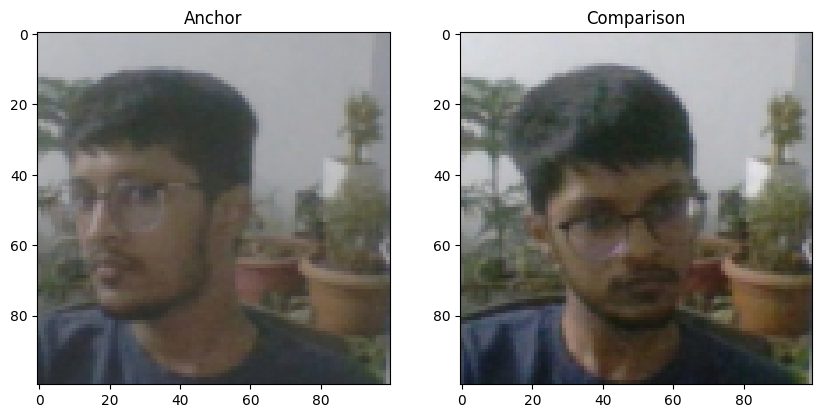

In [19]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(anchor_batch.cpu()[2].permute(1,2,0))
plt.title("Anchor")

plt.subplot(1,2,2)
plt.imshow(other_batch.cpu()[2].permute(1,2,0))
plt.title("Comparison")
plt.show()

In [28]:
def preprocess_pytorch(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = T.ToTensor()(cv2.resize(img, (100,100)))
    return img.unsqueeze(0).to(device)  # (1,3,100,100)

def verify(model, detection_threshold=0.5, verification_threshold=0.7):
    results = []

    input_img = preprocess_pytorch(cv2.imread("application data/input image/input image.jpg"))

    for image in os.listdir("application data/verification image"):
        validation_img = preprocess_pytorch(cv2.imread(f"application data/verification image/{image}"))

        with torch.no_grad():
            logit = model(input_img, validation_img)
            prob = torch.sigmoid(logit).item()
        results.append(prob)

    detections = sum(np.array(results) > detection_threshold)
    verification = detections / len(results)
    verified = verification > verification_threshold

    return results, verified

In [29]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    frame_crop = frame[120:370, 200:450, :]  # same crop
    cv2.imshow("Verification", frame_crop)

    if cv2.waitKey(1) & 0xFF == ord('v'):
        cv2.imwrite("application data/input image/input image.jpg", frame_crop)

        results, verified = verify(model)
        print("Verified:", verified)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Verified: False
Verified: False
Verified: False
Verified: False
Verified: False
Verified: False
Verified: False
Verified: False
Verified: False
Verified: True
Verified: True
Verified: True
Verified: False
Verified: True
Verified: False
Verified: True
Verified: True
Verified: True
Verified: True
Verified: True
Verified: True
Verified: True
Verified: True
Verified: True
Verified: True
Verified: True
Verified: True
Verified: False
Verified: False
Verified: False
Verified: False
Verified: False
Verified: False
Verified: False
